# 04 · Sales Forecasting

**Goal:** forecast daily revenue for the next **8 weeks** and choose the model by objective backtest
metrics, not by preference. Code: `machine_learning/forecasting/forecast.py`.

**Method**
- **Rolling-origin backtest.** Seven times, every 4 weeks, each model is trained only on data before
  the origin and forecasts the next 56 days. Errors are measured on data the model never saw.
- **Candidates:** two baselines (seasonal naive and 4-week weekday average), Ridge regression, Random
  Forest and XGBoost.
- **ML design:** direct multi-horizon training that predicts revenue relative to the last 28 days, with
  calendar features (weekday, holidays, Black-Friday week).
- **Selection:** lowest MAE.
- **Uncertainty:** an empirical 80% interval built from the selected model's own backtest errors.

In [1]:
import sys
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))   # project root
warnings.filterwarnings("ignore", category=UserWarning)

import json
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from IPython.display import Markdown, display

from nexus_nb import AXIS, GRID, INK, MUTED_FILL, SEQUENTIAL_BLUE, SERIES, brl, query

period = query("SELECT * FROM analytics.v_reporting_period").iloc[0]

from machine_learning.forecasting import forecast as F

run = query("SELECT algorithm, params, metrics FROM ml.model_runs WHERE is_active AND model_name = 'sales_forecast'").iloc[0]
selected = run["algorithm"]
pd.Series({**{k: v for k, v in run["params"].items()}, "selected model": selected}).to_frame("value")

,value
target,daily revenue / mean revenue of the 28 days be...
interval,empirical 10th-90th percentile of actual/forec...
horizon_days,56
training_days,"[2017-02-01, 2018-08-23]"
backtest_folds,7
backtest_step_days,28
selected model,Ridge regression


## 1. Model comparison

| Metric | Meaning |
|---|---|
| **MAE** | Average absolute error in R$ per day. Easy to explain, and used for selection. |
| **RMSE** | Like MAE but penalises large misses more. |
| **MAPE** | Average error as a % of the actual day. Valid here because no day in the window has zero revenue. |
| **R²** | Share of day-to-day variance explained. Daily revenue is noisy, so low values are expected. |
| **Bias %** | Total forecast vs total actual. Positive means the model over-forecasts. |
| **Horizon total APE** | Error on the 8-week **total**, which is what planning usually needs. |

metric,MAE,RMSE,MAPE,R2,Bias %,Horizon total APE
candidate,,,,,,
Ridge regression,"6,152.80","8,013.11",24.02,0.11,8.42,11.61
Weekday average (4 weeks),"6,511.18","8,229.69",23.51,0.06,-3.02,8.65
Seasonal naive (last week),"7,034.26","8,801.22",24.59,-0.07,-3.69,9.59
XGBoost,"7,954.56","10,450.37",30.80,-0.51,8.62,18.95
Random forest,"8,789.88","11,581.36",32.99,-0.86,6.01,17.47


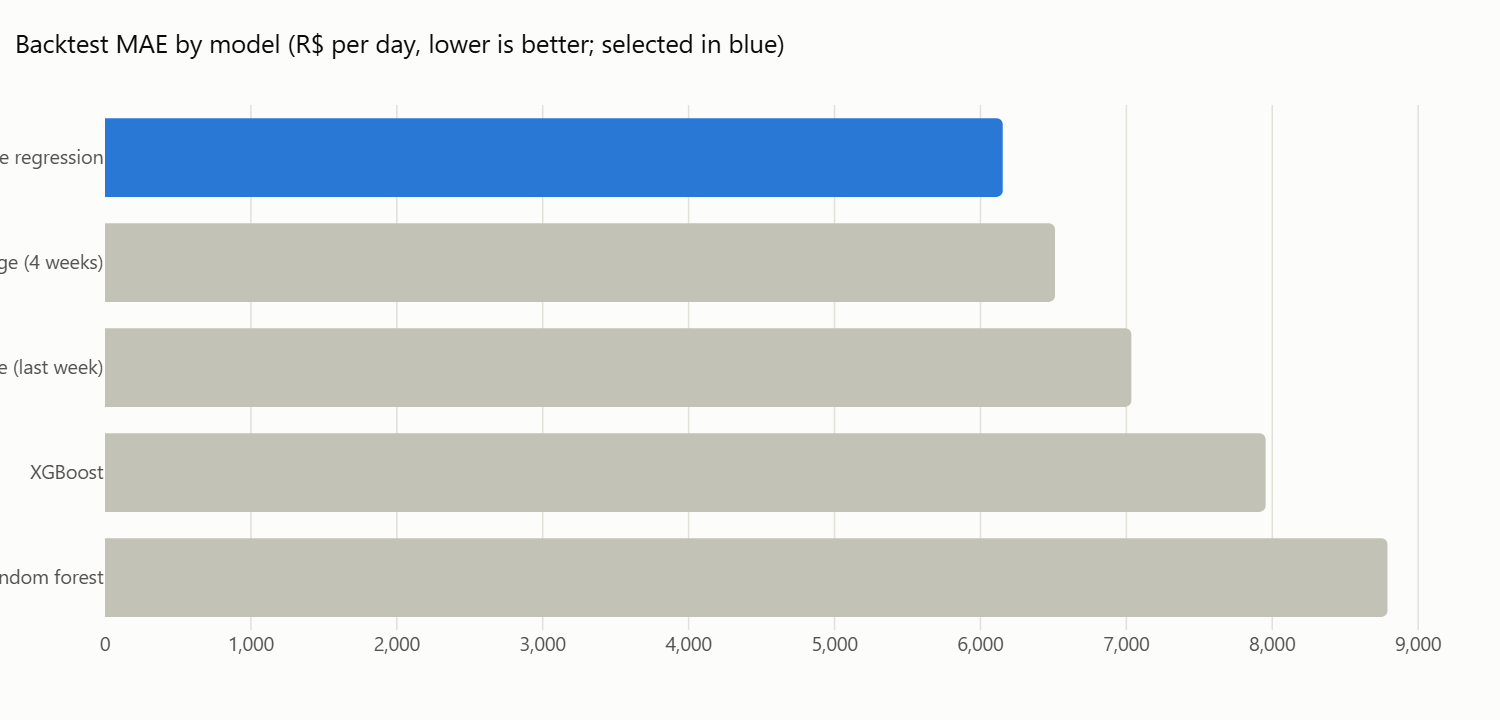

In [2]:
ev = query("""SELECT candidate, metric, value FROM analytics.v_model_evaluations
              WHERE model_name = 'sales_forecast' AND split = 'rolling_backtest'""")
comparison = ev.pivot(index="candidate", columns="metric", values="value")[
    ["MAE", "RMSE", "MAPE", "R2", "Bias %", "Horizon total APE"]].sort_values("MAE")
display(comparison.round(2))

colors = [SERIES[0] if c == selected else MUTED_FILL for c in comparison.index]
fig = go.Figure(go.Bar(x=comparison["MAE"], y=comparison.index, orientation="h", marker_color=colors,
                       hovertemplate="%{y}: MAE R$ %{x:,.0f}<extra></extra>"))
fig.update_layout(title="Backtest MAE by model (R$ per day, lower is better; selected in blue)",
                  xaxis=dict(tickformat=",.0f", showgrid=True, gridcolor=GRID), yaxis=dict(autorange="reversed", showgrid=False),
                  height=380)
fig.show()

## 2. A regime change the models had to handle

Revenue grew quickly through 2017 and plateaued in 2018. An earlier version with a momentum feature
(last 28 days vs the 28 before) learned to extrapolate growth and **over-forecast 2018 by about 15–18%**
in the backtest, so that feature was removed (documented in the code). Note that this choice was
informed by the backtest itself, so the backtest error of the final configuration is slightly optimistic.

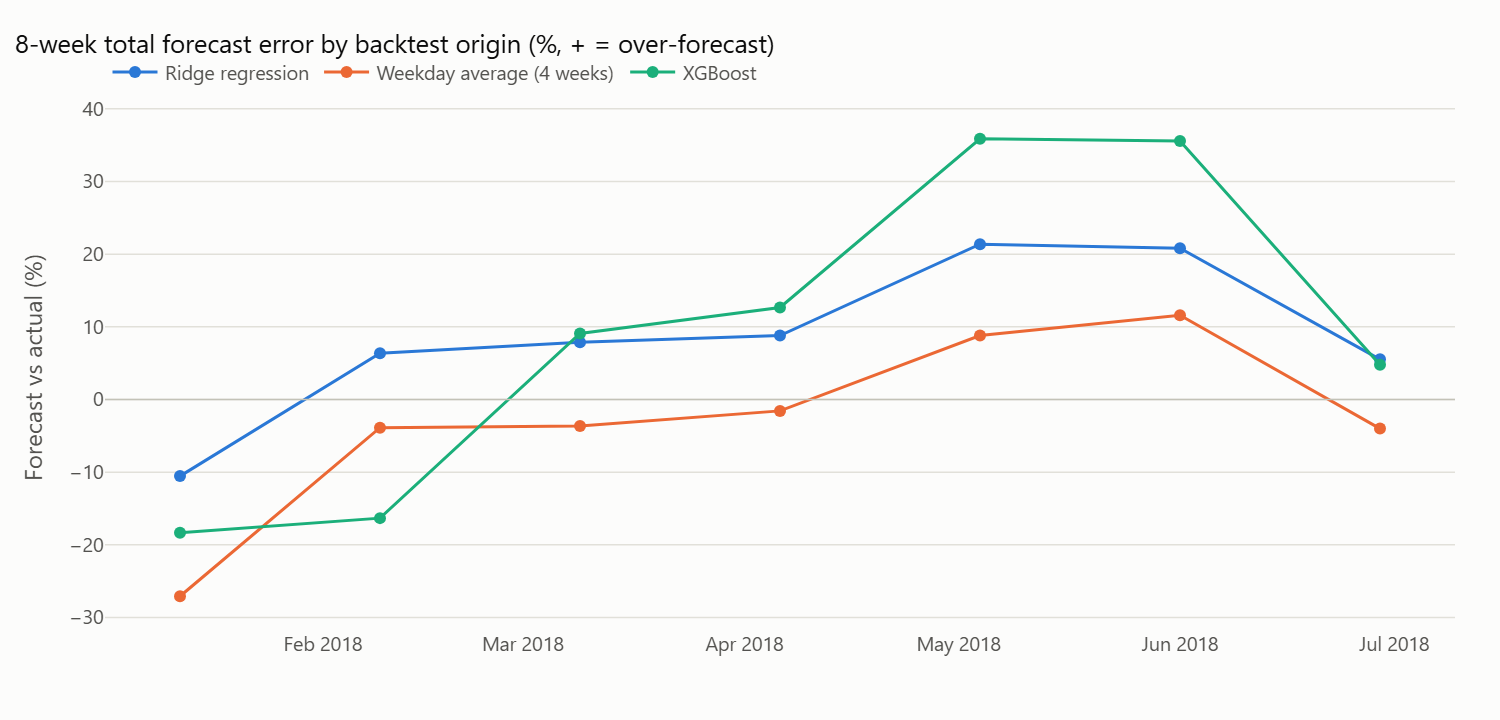

In [3]:
y = F.load_daily_revenue()
bt = F.backtest(y, F.load_holidays())
bias = bt.groupby(["origin", "model"]).apply(lambda g: g["forecast"].sum() / g["actual"].sum() - 1).unstack()

fig = go.Figure()
for i, name in enumerate([selected, "Weekday average (4 weeks)", "XGBoost"]):
    fig.add_scatter(x=bias.index, y=bias[name] * 100, mode="lines+markers", name=name,
                    line=dict(color=SERIES[i], width=2), marker=dict(size=8),
                    hovertemplate=name + " · origin %{x|%d %b %Y}: %{y:+.1f}%<extra></extra>")
fig.add_hline(y=0, line=dict(color=AXIS, width=1))
fig.update_layout(title="8-week total forecast error by backtest origin (%, + = over-forecast)",
                  yaxis_title="Forecast vs actual (%)")
fig.show()

## 3. The forecast

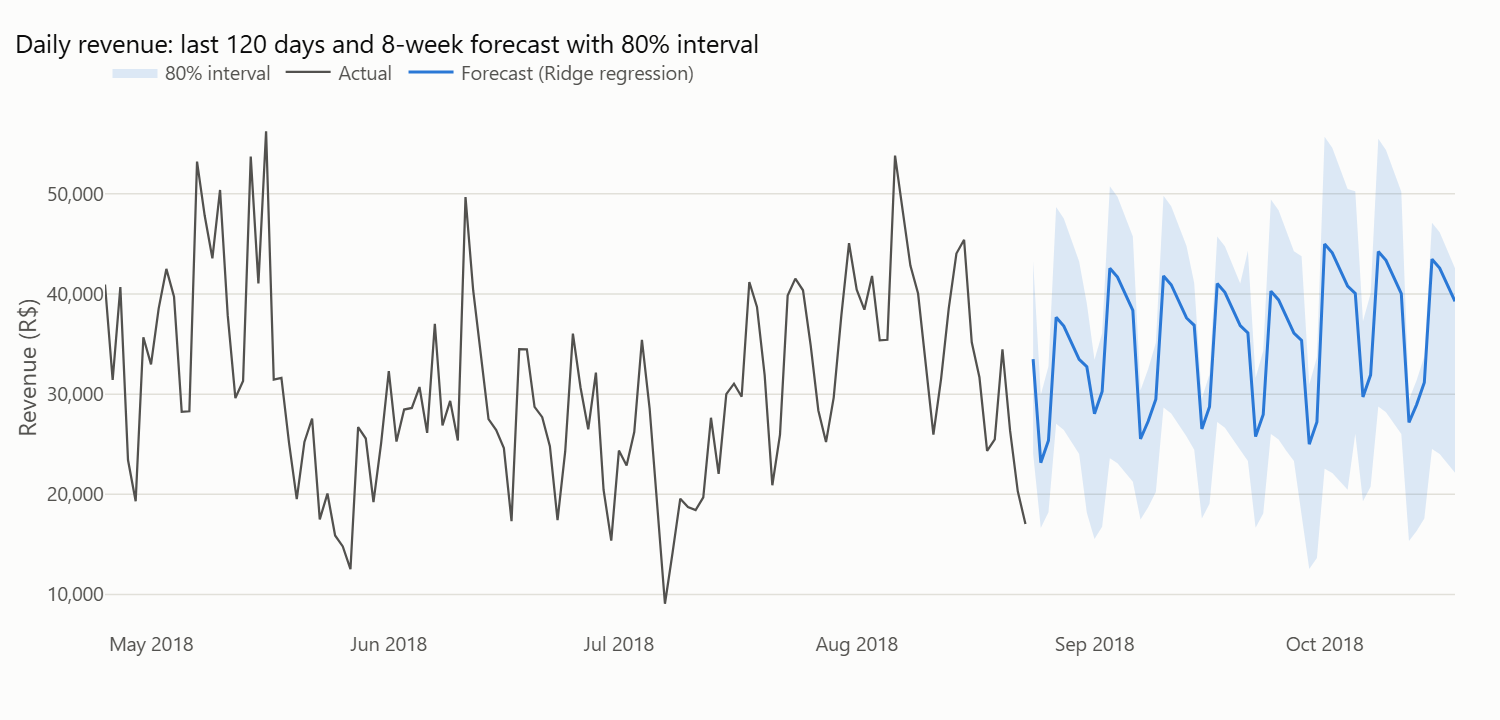

,forecast,lower_80,upper_80
day,,,
2018-08-26,"82,020.00","58,899.00","105,985.00"
2018-09-02,"234,029.00","153,148.00","293,318.00"
2018-09-09,"244,858.00","146,538.00","291,856.00"
2018-09-16,"251,649.00","170,469.00","292,661.00"
2018-09-23,"246,328.00","161,855.00","284,600.00"
2018-09-30,"241,006.00","143,078.00","296,658.00"
2018-10-07,"273,951.00","152,495.00","340,765.00"
2018-10-14,"256,518.00","159,276.00","306,907.00"
2018-10-21,"166,175.00","93,777.00","180,134.00"


In [4]:
fc = query("SELECT * FROM analytics.v_sales_forecast ORDER BY day")
fc["day"] = pd.to_datetime(fc["day"])
hist = fc[(fc["kind"] == "actual") & (fc["day"] >= fc.loc[fc["kind"] == "actual", "day"].max() - pd.Timedelta(days=120))]
fut = fc[fc["kind"] == "forecast"]   # forecast values are in the revenue column

fig = go.Figure()
fig.add_scatter(x=pd.concat([fut["day"], fut["day"][::-1]]), y=pd.concat([fut["upper_80"], fut["lower_80"][::-1]]),
                fill="toself", fillcolor="rgba(42,120,214,0.15)", line=dict(width=0), name="80% interval",
                hoverinfo="skip")
fig.add_scatter(x=hist["day"], y=hist["revenue"], mode="lines", name="Actual", line=dict(color=INK["secondary"], width=1.5),
                hovertemplate="%{x|%a %d %b}: R$ %{y:,.0f}<extra></extra>")
fig.add_scatter(x=fut["day"], y=fut["revenue"], mode="lines", name=f"Forecast ({selected})",
                line=dict(color=SERIES[0], width=2), hovertemplate="%{x|%a %d %b}: R$ %{y:,.0f}<extra></extra>")
fig.update_layout(title="Daily revenue: last 120 days and 8-week forecast with 80% interval",
                  yaxis=dict(title="Revenue (R$)", tickformat=",.0f"))
fig.show()

weekly = fut.set_index("day")[["revenue", "lower_80", "upper_80"]].rename(columns={"revenue": "forecast"}).resample("W-SUN").sum()
weekly.round(0)

Weekly bounds above are sums of daily bounds, which assumes errors move together. They are therefore
a conservative (wide) range, not a statistically exact weekly interval.

## 4. Findings

Generated from the results above.

In [5]:
best_base = comparison.loc[[c for c in comparison.index if c in F.BASELINES]].sort_values("MAE").iloc[0]
sel = comparison.loc[selected]
m = run["metrics"]
display(Markdown(f"""
1. **{selected}** has the lowest backtest MAE (**R$ {sel['MAE']:,.0f}/day**, MAPE {sel['MAPE']:.1f}%), beating the best baseline
   ({best_base.name}, R$ {best_base['MAE']:,.0f}/day) by {1 - sel['MAE'] / best_base['MAE']:.1%}.
2. **The margin over simple methods is small, and that is itself a finding.** On the 8-week **total** the
   {best_base.name.lower()} baseline errs {best_base['Horizon total APE']:.1f}% vs {sel['Horizon total APE']:.1f}% for {selected}. The two
   tree models perform worst (R² {comparison.loc['XGBoost', 'R2']:.2f} and {comparison.loc['Random forest', 'R2']:.2f}). With about 19 months of
   history, one Black Friday and a regime change, added complexity does not pay off.
3. **Forecast:** next 8 weeks ≈ **{brl(m['forecast_total'])}**. The 80% daily interval covered **{m['interval_coverage_out_of_fold']:.0%}** of
   actual days in out-of-fold checks, slightly below the nominal 80%, so the ranges should be read as indicative.
4. **Predictions are estimates, not certainties.** The interval is shown everywhere the forecast is.
"""))


1. **Ridge regression** has the lowest backtest MAE (**R$ 6,153/day**, MAPE 24.0%), beating the best baseline
   (Weekday average (4 weeks), R$ 6,511/day) by 5.5%.
2. **The margin over simple methods is small, and that is itself a finding.** On the 8-week **total** the
   weekday average (4 weeks) baseline errs 8.7% vs 11.6% for Ridge regression. The two
   tree models perform worst (R² -0.51 and -0.86). With about 19 months of
   history, one Black Friday and a regime change, added complexity does not pay off.
3. **Forecast:** next 8 weeks ≈ **R$ 1,996,535**. The 80% daily interval covered **74%** of
   actual days in out-of-fold checks, slightly below the nominal 80%, so the ranges should be read as indicative.
4. **Predictions are estimates, not certainties.** The interval is shown everywhere the forecast is.
